In [79]:
import pandas as pd

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier

from sklearn.preprocessing import StandardScaler , OneHotEncoder 

from sklearn.model_selection import train_test_split 

from sklearn.metrics import classification_report , confusion_matrix , RocCurveDisplay, roc_auc_score

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer

from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings("ignore")


# Load Data

In [80]:
data = pd.read_csv("data_ecommerce_customer_churn.csv")

In [81]:
data

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
...,...,...,...,...,...,...,...,...,...,...,...
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0
3938,30.0,6.0,5,Laptop & Accessory,3,Married,3,1,2.0,156.60,0
3939,6.0,NaN,4,Mobile,3,Married,10,1,0.0,124.37,1


In [82]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   str    
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   str    
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 411.2 KB


In [83]:
data.describe()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3747.000000,3772.000000,3941.000000,3941.000000,3941.000000,3941.000000,3728.000000,3941.000000,3941.000000
mean,10.081398,15.650583,3.679269,3.088302,4.237757,0.282416,4.531652,176.707419,0.171023
std,8.498864,8.452301,1.013938,1.381832,2.626699,0.450232,3.667648,48.791784,0.376576
min,0.000000,5.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,9.000000,3.000000,2.000000,2.000000,0.000000,2.000000,145.700000,0.000000
50%,9.000000,14.000000,4.000000,3.000000,3.000000,0.000000,3.000000,163.340000,0.000000
75%,16.000000,21.000000,4.000000,4.000000,6.000000,1.000000,7.000000,195.250000,0.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,1.000000,46.000000,324.990000,1.000000


In [84]:
data.describe(include="object")

,PreferedOrderCat,MaritalStatus
count,3941,3941
unique,6,3
top,Laptop & Accessory,Married
freq,1458,2055


# EDA

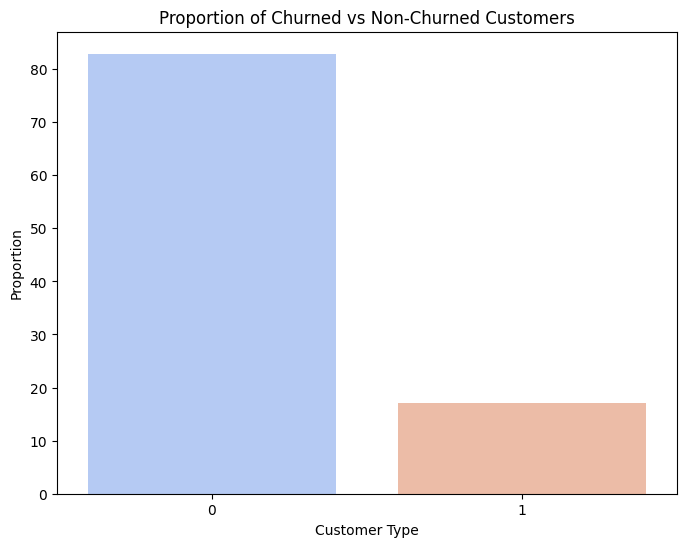

In [85]:
balance_perc = pd.DataFrame(data["Churn"].value_counts(normalize=True)*100)

plt.figure(figsize=(8,6))
sns.barplot(data=balance_perc,x=balance_perc.index,y="proportion",palette="coolwarm")
plt.title("Proportion of Churned vs Non-Churned Customers")
plt.xlabel("Customer Type")
plt.ylabel("Proportion")
plt.show()

In [86]:
data.isnull().sum()

Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

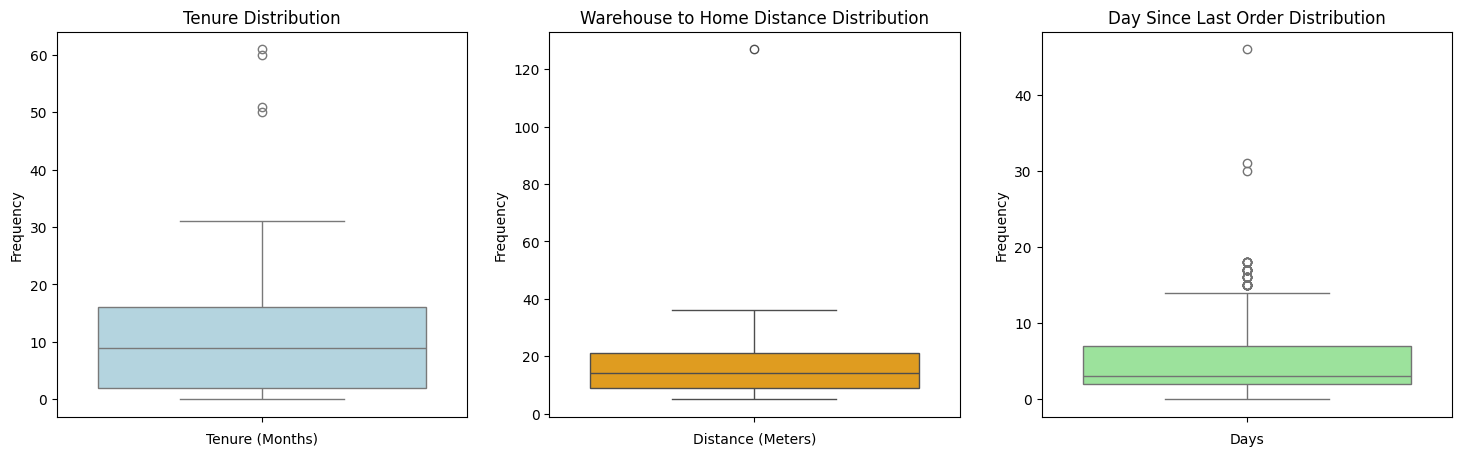

In [87]:
fig , ax = plt.subplots(1,3,figsize=(18,5))

sns.boxplot(data=data,y="Tenure",ax=ax[0],color="lightblue")
ax[0].set_title("Tenure Distribution")
ax[0].set_xlabel("Tenure (Months)")
ax[0].set_ylabel("Frequency")

sns.boxplot(data=data,y="WarehouseToHome",ax=ax[1],color="orange")
ax[1].set_title("Warehouse to Home Distance Distribution")
ax[1].set_xlabel("Distance (Meters)")
ax[1].set_ylabel("Frequency")


sns.boxplot(data=data,y="DaySinceLastOrder",ax=ax[2],color="lightgreen")
ax[2].set_title("Day Since Last Order Distribution")
ax[2].set_xlabel("Days")
ax[2].set_ylabel("Frequency")

plt.show()

In [88]:
data["MaritalStatus"].value_counts()

MaritalStatus
Married     2055
Single      1310
Divorced     576
Name: count, dtype: int64

In [89]:
data["PreferedOrderCat"].value_counts()

PreferedOrderCat
Laptop & Accessory    1458
Mobile Phone           887
Fashion                585
Mobile                 559
Grocery                273
Others                 179
Name: count, dtype: int64

In [90]:
data["PreferedOrderCat"] = data["PreferedOrderCat"].replace({"Mobile Phone":"Mobile"})

In [91]:
numerical_features = data.select_dtypes(include=[np.number]).columns.tolist()

categorical_features = data.select_dtypes(include=[object]).columns.tolist()

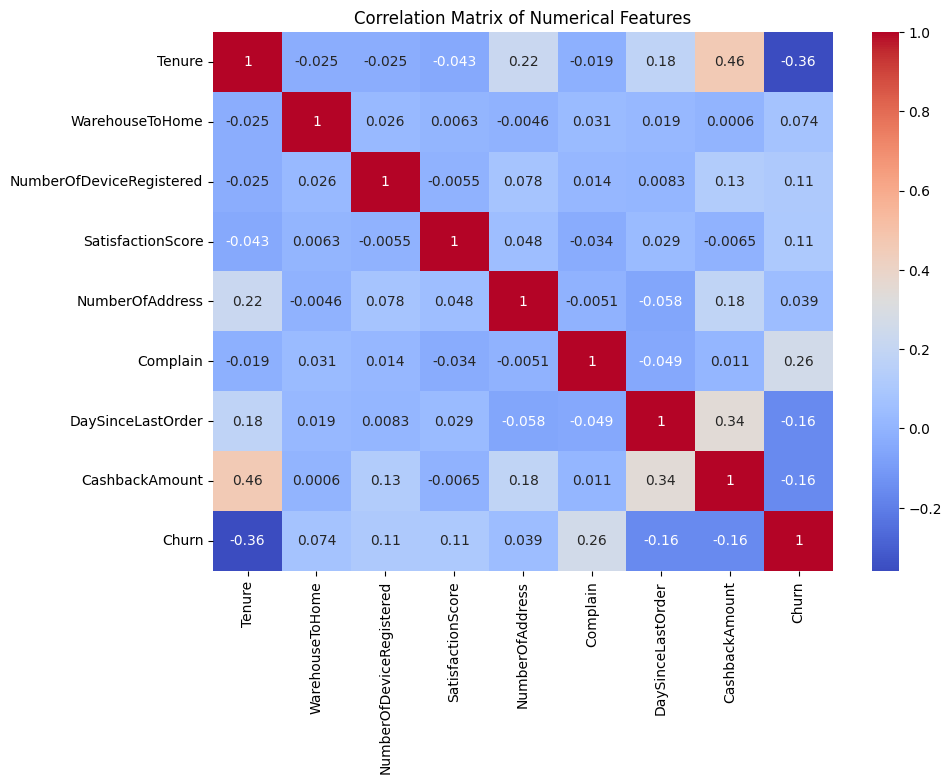

In [92]:
plt.figure(figsize=(10,7))
cm = data[numerical_features].corr()

sns.heatmap(cm,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

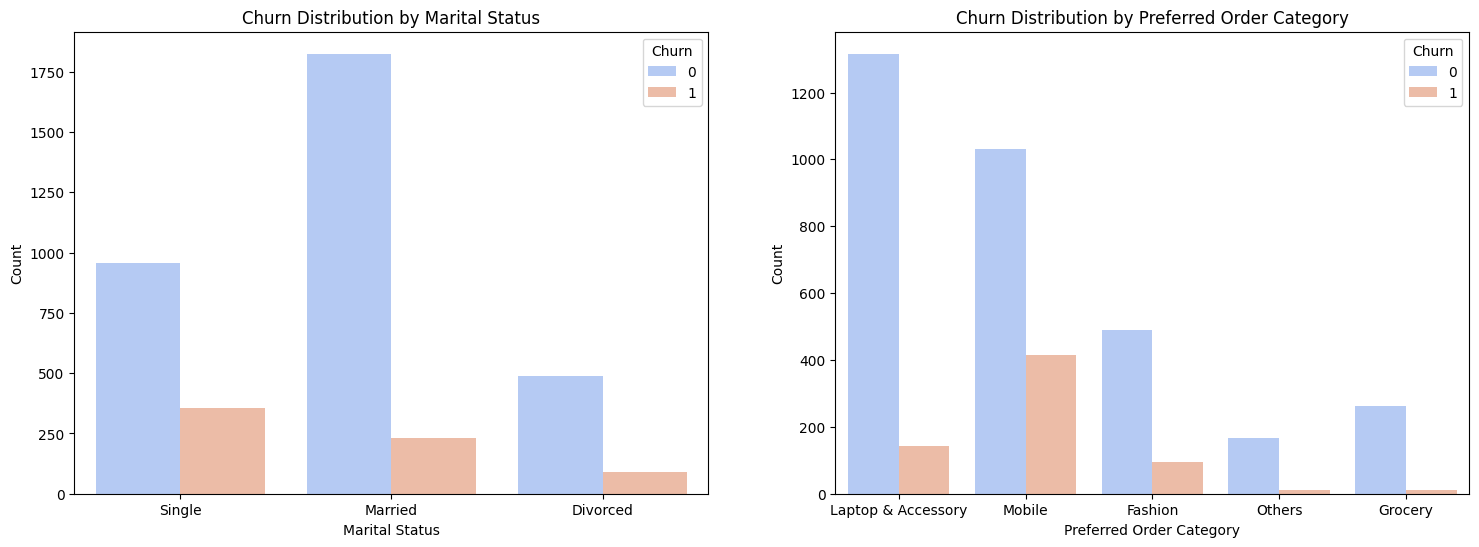

In [93]:
fig ,ax = plt.subplots(1,2,figsize=(18,6))

sns.countplot(data=data,x="MaritalStatus",hue="Churn",ax=ax[0],palette="coolwarm")
ax[0].set_title("Churn Distribution by Marital Status")
ax[0].set_xlabel("Marital Status")
ax[0].set_ylabel("Count")

sns.countplot(data=data,x="PreferedOrderCat",hue="Churn",ax=ax[1],palette="coolwarm")
ax[1].set_title("Churn Distribution by Preferred Order Category")
ax[1].set_xlabel("Preferred Order Category")
ax[1].set_ylabel("Count")   
plt.show()

# Data Preprocessing & Feature Engineering

In [94]:
data.isnull().sum()

Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

In [95]:
X = data.drop("Churn",axis=1)
Y = data["Churn"]

In [96]:
X.shape , Y.shape

((3941, 10), (3941,))

In [97]:
X["Dissatisfaction_Score"] = X["Complain"] * (5 - X["SatisfactionScore"])

X["Cashback_Per_Tenure"] = X["CashbackAmount"] / (X["Tenure"] + 1)  


In [98]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y) 
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (3152, 12) (3152,)
Testing set shape: (789, 12) (789,)


In [99]:
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

categorical_features = X.select_dtypes(include=[object]).columns.tolist()

In [100]:
numeric_transformer = Pipeline(
    [   
        ("Imputer", KNNImputer(n_neighbors=5)),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    [
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Model Building

In [101]:
RF_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
    ]
)

Ada_boost_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", AdaBoostClassifier(n_estimators=100, random_state=42))
    ]
)

In [102]:
Ada_boost_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [103]:
RF_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [104]:
ada_boost_y_pred = Ada_boost_model.predict(X_test)
rf_y_pred = RF_model.predict(X_test)

In [105]:
print("AdaBoost Classification Report:\n", classification_report(y_test, ada_boost_y_pred))

AdaBoost Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.93       654
           1       0.67      0.51      0.58       135

    accuracy                           0.87       789
   macro avg       0.79      0.73      0.75       789
weighted avg       0.86      0.87      0.87       789



In [106]:
print("Random Forest Classification Report:\n", classification_report(y_test, rf_y_pred))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96       654
           1       0.90      0.73      0.80       135

    accuracy                           0.94       789
   macro avg       0.92      0.85      0.88       789
weighted avg       0.94      0.94      0.94       789



## Grid Search

In [107]:
param_grid_ada = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.1, 0.5, 1.0]
}

grid_ada = GridSearchCV(
    estimator=Ada_boost_model,  
    param_grid=param_grid_ada,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_ada.fit(X_train,y_train)

best_ada_pipeline = grid_ada.best_estimator_
print("Best AdaBoost Params:", grid_ada.best_params_)
print("Best AdaBoost F1 Score:", grid_ada.best_score_)

Best AdaBoost Params: {'classifier__learning_rate': 1.0, 'classifier__n_estimators': 200}
Best AdaBoost F1 Score: 0.6475285050669666


# Evaluation

In [108]:
y_pred_ada = best_ada_pipeline.predict(X_test)
y_pred_rf = RF_model.predict(X_test)

y_proba_ada = best_ada_pipeline.predict_proba(X_test)[:, 1]
y_proba_rf = RF_model.predict_proba(X_test)[:, 1]

In [109]:
print("=== Best AdaBoost Classification Report ===")
print(classification_report(y_test, y_pred_ada))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_ada):.4f}\n")

print("=== Best Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}\n")

=== Best AdaBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       654
           1       0.70      0.51      0.59       135

    accuracy                           0.88       789
   macro avg       0.80      0.73      0.76       789
weighted avg       0.87      0.88      0.87       789

ROC-AUC Score: 0.9031

=== Best Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       654
           1       0.90      0.73      0.80       135

    accuracy                           0.94       789
   macro avg       0.92      0.85      0.88       789
weighted avg       0.94      0.94      0.94       789

ROC-AUC Score: 0.9587



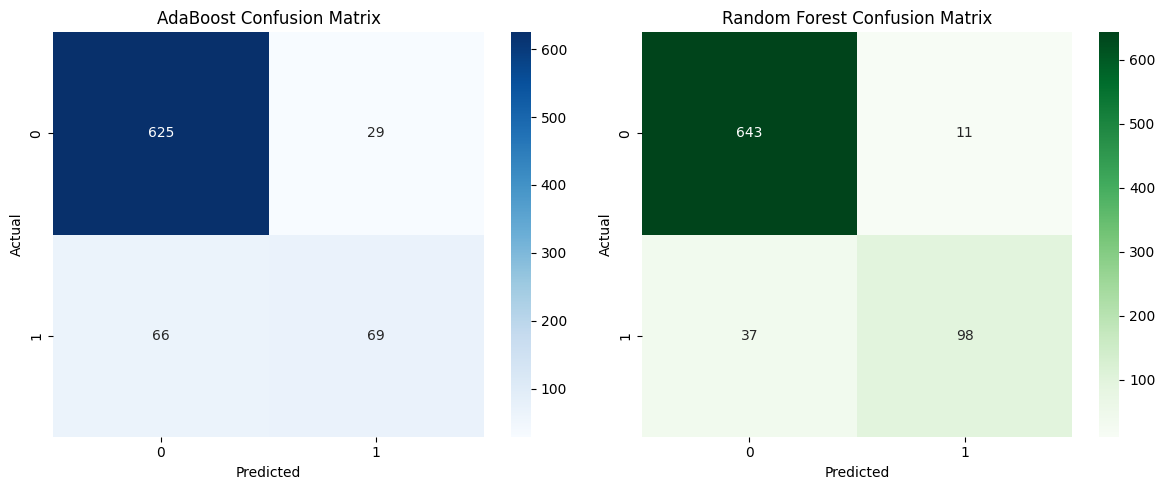

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_ada), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('AdaBoost Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

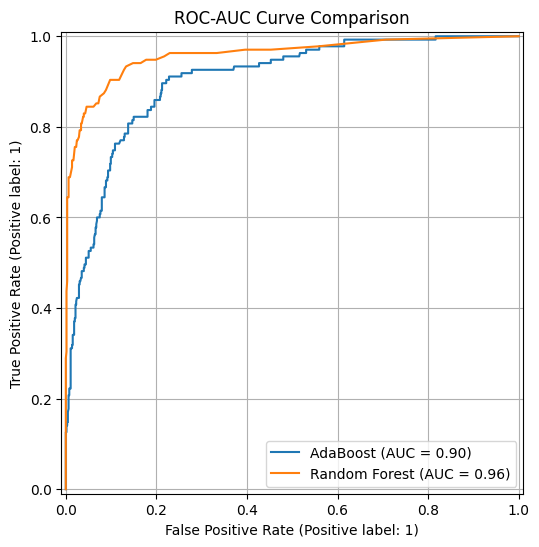

In [111]:
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_ada, name='AdaBoost', ax=plt.gca())
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name='Random Forest', ax=plt.gca())
plt.title('ROC-AUC Curve Comparison')
plt.grid(True)
plt.show()

# Save Model

In [112]:
import joblib
joblib.dump(best_ada_pipeline, 'best_ada_pipeline.pkl')
joblib.dump(RF_model, 'best_rf_pipeline.pkl')
joblib.dump(list(X.columns), 'ecommerce_customer_churn_features.pkl') 

['ecommerce_customer_churn_features.pkl']